# Species occurrences near Pine Ridge

This example resolves a scientific name, retrieves a bounded GBIF search, summarizes quality and draws an aggregated map plus record history. Change the parameters below to explore another species. Species selection does not itself establish cultural significance; use community-approved context or a cited source for that description.

The rectangle is a regional search area, not a reservation boundary. No assertion is made that records fall inside Pine Ridge Reservation. For a reservation-specific analysis, obtain the appropriate boundary and clip point geometry before aggregation; record its source/vintage and coordinate system.


In [ ]:
# Imports
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / "species.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "species.csv").exists():
    raise RuntimeError("Run from the repository root or notebooks directory.")
sys.path.insert(0, str(ROOT / "src"))
from occurrences import retrieve, draw_summary
import pandas as pd


In [ ]:
# Details for GBIF
SCIENTIFIC_NAME = "Prunus virginiana"
BBOX = (-103.5, 42.5, -101.5, 43.8)  # west, south, east, north; longitude/latitude
YEARS = (1900, 2025)
REFRESH = False  # Reuses matching local snapshot; True saves a separate new snapshot.


## Retrieve records

Search pages are limited to 300 records. The helper retrieves all pages for this selection up to a 3,000-record cap and stops with instructions if the match count exceeds that cap. It does not silently plot an incomplete sample. Names must match at species rank; review ambiguous names manually. An accepted name/key is resolved before querying.

The public search endpoint requires no account. Official GBIF downloads require an account and provide a download DOI; see the README for that workflow. Search snapshots can change as records are updated.


In [3]:
snapshot = retrieve(SCIENTIFIC_NAME, BBOX, YEARS, ROOT / "data", refresh=REFRESH)
print("Matched:", snapshot["taxon"]["matched_name"])
print("Accepted:", snapshot["taxon"]["accepted_name"], snapshot["taxon"]["accepted_key"])
print("Retrieved UTC:", snapshot["retrieved_utc"])
print("Records:", len(snapshot["records"]), "Pages:", len(snapshot["pages"]))


Matched: Prunus virginiana L.
Accepted: Prunus virginiana L. 3022668
Retrieved UTC: 2026-09-05T18:07:04.238051+00:00
Records: 164 Pages: 1


## Visualize and inspect quality

Approximate 0.2-degree map cells with fewer than three records are hidden. These are record counts, not abundance or equal-area densities. Empty space does not establish species absence. Historical record counts reflect changing collection effort as well as data publication. Query filters already exclude records without a year/coordinates and those flagged with geospatial issues.

Before sharing a different species' visualization, apply relevant guidance for sensitive species and community knowledge. This example does not publish exact locations.


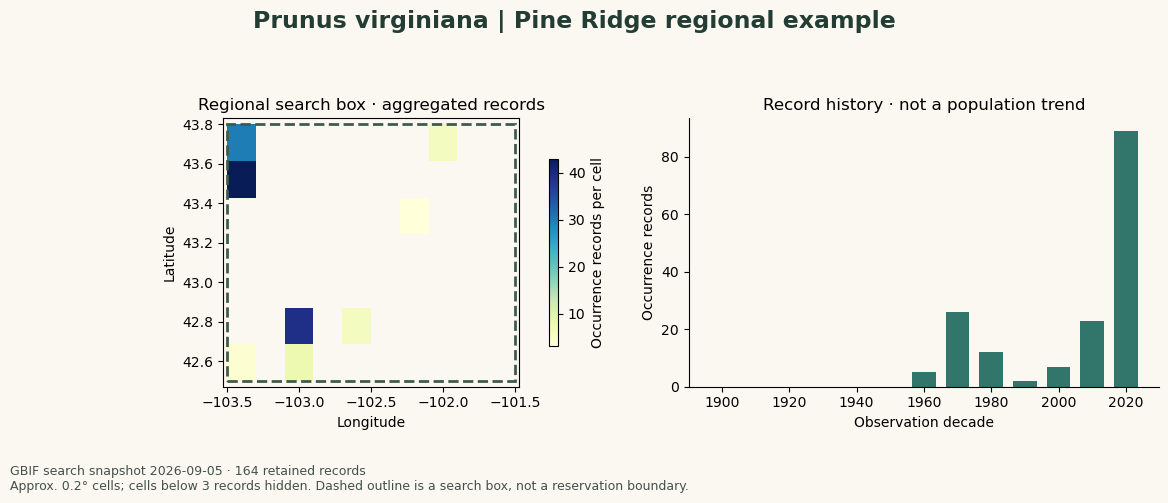

,Measure,Value
0,retrieved_records,164
1,mapped_records,164
2,excluded_locally,0
3,duplicate_keys_removed,0
4,missing_event_date,0
5,missing_year,0
6,missing_coordinate_uncertainty,31
7,uncertainty_above_10km,7
8,earliest_year,1964
9,latest_year,2025


,Records by basisOfRecord
HUMAN_OBSERVATION,100
PRESERVED_SPECIMEN,64


In [ ]:
figure, quality = draw_summary(snapshot, ROOT/"outputs"/"occurrences.png")
display(figure)
import matplotlib.pyplot as plt
plt.close(figure)
display(pd.DataFrame([(k, v) for k, v in quality.items() if k != "record_types"], columns=["Measure", "Value"]))
display(pd.Series(quality["record_types"], name="Records by basisOfRecord").to_frame())


## Attribution and interpretation

The ignored snapshot retains occurrence identifiers, dataset keys, source licenses, event dates, coordinate uncertainty, query parameters and taxonomic match details. Duplicate GBIF keys are removed; this does not detect every duplicate specimen or observation across datasets. Large or missing coordinate uncertainty remains visible in the quality summary and is not treated as zero.

Use the source dataset pages for attribution and an official GBIF download DOI for research outputs. The repository's MIT license does not replace source licenses or applicable Tribal guidance. A regional collection such as the High Plains Herbarium may include records near the reservation; its institutional description alone does not establish in-boundary occurrence coverage.
